In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes  # Dataset regresi bawaan yang aman
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor  # Algoritma Gradient Boosting
from sklearn.metrics import mean_squared_error, r2_score

# Memuat dataset diabetes
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='Progression')

# Menggabungkan fitur dan target untuk melihat ringkasan data
df_clean = pd.concat([X, y], axis=1)

print("=== DATASET REGRESI BERHASIL DI-LOAD ===")
print(f"Dimensi Dataset: {df_clean.shape}")
df_clean.head()

=== DATASET BERHASIL DI-LOAD (TANPA FILE EXTERNAL) ===
Dimensi Dataset: (178, 14)
Nama Kelas Target: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


C:\Users\ThinkPad\AppData\Local\Temp\ipykernel_5408\2320285135.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


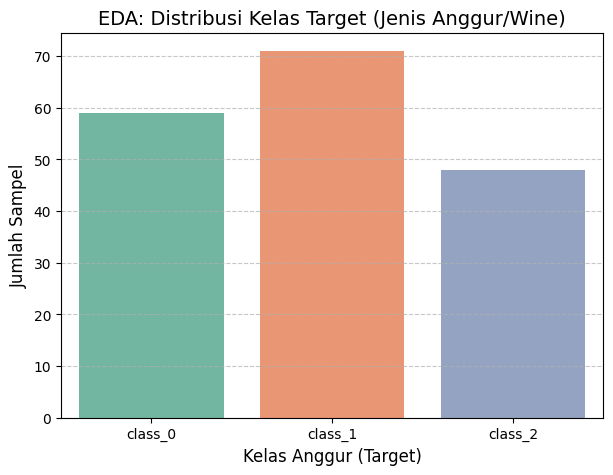

In [2]:
# Visualisasi Distribusi Kelas Target menggunakan Bar Chart
plt.figure(figsize=(7, 5))
sns.countplot(x=y, palette='Set2')

plt.title('EDA: Distribusi Kelas Target (Jenis Anggur/Wine)', fontsize=14)
plt.xlabel('Kelas Anggur (Target)', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.xticks([0, 1, 2], wine.target_names)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [4]:
# Membagi data menjadi 80% Latih dan 20% Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standarisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

# Model 2: K-Nearest Neighbors (KNN)
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

print("=== PROSES TRAINING SELESAI ===")

=== PROSES TRAINING SELESAI ===


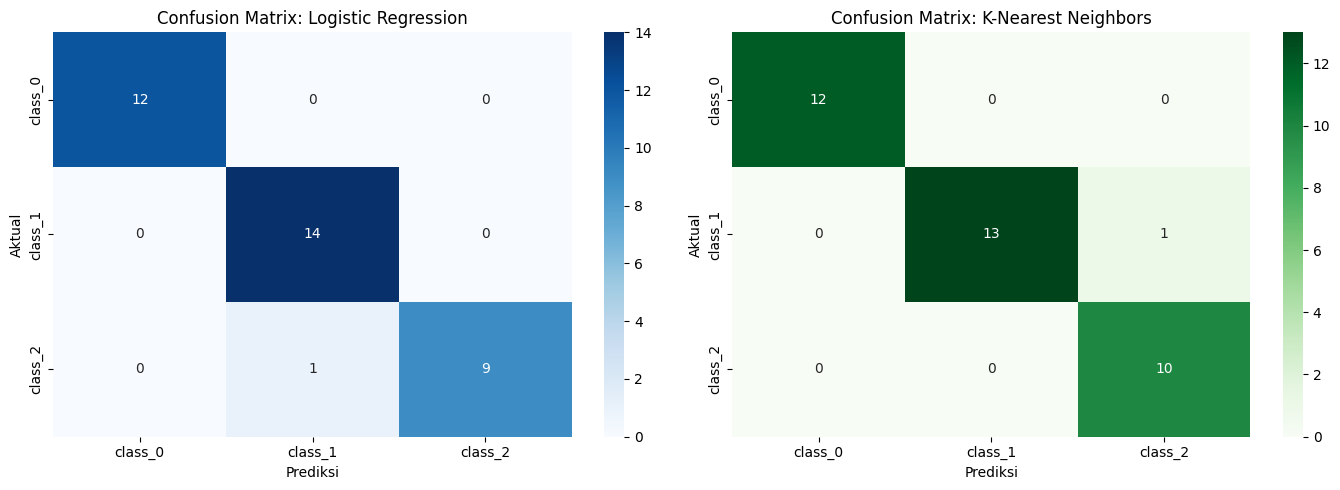


=== HASIL EVALUASI PERFORMA MODEL ===
Logistic Regression -> Akurasi: 97.22%, Recall (Macro): 96.67%
K-Nearest Neighbors -> Akurasi: 97.22%, Recall (Macro): 97.62%


In [5]:
# Menampilkan Confusion Matrix berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')
axes[0].set_xticklabels(wine.target_names)
axes[0].set_yticklabels(wine.target_names)

# Heatmap KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix: K-Nearest Neighbors')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')
axes[1].set_xticklabels(wine.target_names)
axes[1].set_yticklabels(wine.target_names)

plt.tight_layout()
plt.show()

# Menampilkan metrik utama
print("\n=== HASIL EVALUASI PERFORMA MODEL ===")
print(f"Logistic Regression -> Akurasi: {accuracy_score(y_test, y_pred_lr):.2%}, Recall (Macro): {recall_score(y_test, y_pred_lr, average='macro'):.2%}")
print(f"K-Nearest Neighbors -> Akurasi: {accuracy_score(y_test, y_pred_knn):.2%}, Recall (Macro): {recall_score(y_test, y_pred_knn, average='macro'):.2%}")